# 正确率方差分析

开始读取目录: /Users/zhangqianqian/Documents/PKU/实验/实验三数据
目录中找到 36 个Excel文件
处理文件 1/36: chujue_2101_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2101
处理文件 2/36: chujue_2102_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2102
处理文件 3/36: chujue_2103_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2103
处理文件 4/36: chujue_2104_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2104
处理文件 5/36: chujue_2105_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2105
处理文件 6/36: chujue_2106_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2106
处理文件 7/36: chujue_2107_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2107
处理文件 8/36: chujue_2108_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2108
处理文件 9/36: chujue_2109_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2109
处理文件 10/36: chujue_2110_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2110
处理文件 11/36: chujue_2111_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2111
处理文件 12/36: chujue_2112_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2112
处理文件 13/36: chujue_2113_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2113
处理文件 14/36: chujue_2114_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2114
处理文件 15/36: chujue_2115_1_1.xlsx
  - 包含 192 行数据
  - 被试ID:

/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


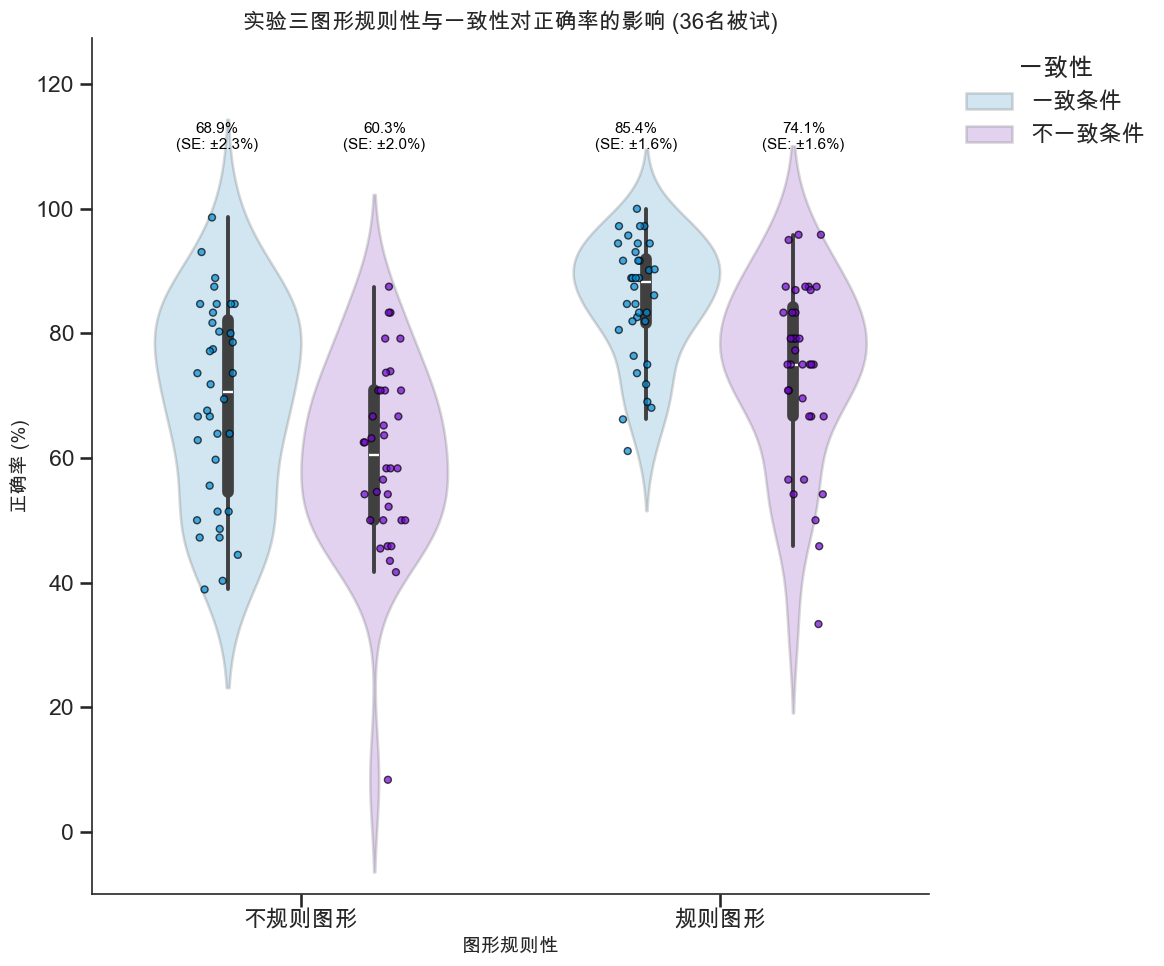



====== 报 告 专 用 数 据 (正确率, 校正后) ======
[不规则图形 - 一致条件]
  均值 (Mean)  : 68.9%
  标准误 (SE)  : ±2.3%
  95%置信区间 : [64.3%, 73.5%] (半宽: ±4.6%)
---------------------------------------------
[不规则图形 - 不一致条件]
  均值 (Mean)  : 60.3%
  标准误 (SE)  : ±2.0%
  95%置信区间 : [56.3%, 64.3%] (半宽: ±4.0%)
---------------------------------------------
[规则图形 - 一致条件]
  均值 (Mean)  : 85.4%
  标准误 (SE)  : ±1.6%
  95%置信区间 : [82.2%, 88.5%] (半宽: ±3.2%)
---------------------------------------------
[规则图形 - 不一致条件]
  均值 (Mean)  : 74.1%
  标准误 (SE)  : ±1.6%
  95%置信区间 : [70.8%, 77.4%] (半宽: ±3.3%)
---------------------------------------------


====== 主效应统计与正文文字生成 ======
【你可以直接复制以下这段话放入论文中】
对受试者正确率的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间未表现出显著的交互作用（F(1, 35) = 0.84, p = .364, ηp² = 0.002）。由于交互作用不显著，分析重点转向两大主效应。
结果表明，注意一致性的主效应...（F(1, 35) = 19.87, p < .001, ηp² = 0.113）：由于其不具有主效应效应，所以被试在注意一致条件下的正确率（M = 77.1%, 95% CI [73.9%, 80.3%]）与注意不一致条件（M = 67.2%, 95% CI [64.0%, 70.4%]）相近[请根据实际p值自行修改描述]。
同理，语义规则性的主效应...（F(1, 35) = 68.41, p < .001, ηp²

In [1]:
# 多份文件的数据处理与方差分析 - 正确率分析
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from matplotlib.font_manager import FontProperties
import traceback

# 设置中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'PingFang SC', 'Microsoft YaHei', 'STHeiti', 'Heiti SC', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'sans-serif'
    font = FontProperties(family='sans-serif', size=12)
except Exception as e:
    print(f"字体设置出错: {e}")

# 创建输出文件夹
output_folder = os.path.join(os.getcwd(), '多被试分析结果_ANOVA')
os.makedirs(output_folder, exist_ok=True)

# 数据文件路径
data_path = '/Users/zhangqianqian/Documents/PKU/实验/实验三数据'

try:
    # 读取并合并所有数据
    all_data = []
    subject_count = 0
    file_count = 0
    
    # 检查目录是否存在
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"找不到目录: {data_path}")
    
    print(f"开始读取目录: {data_path}")
    
    # 列出所有文件
    all_files = sorted(os.listdir(data_path))
    excel_files = [f for f in all_files if f.lower().endswith(('.xlsx', '.xls'))]
    
    print(f"目录中找到 {len(excel_files)} 个Excel文件")
    
    # 处理每个文件
    for file_name in excel_files:
        try:
            file_count += 1
            file_path = os.path.join(data_path, file_name)
            print(f"处理文件 {file_count}/{len(excel_files)}: {file_name}")
            
            # 读取Excel文件
            df = pd.read_excel(file_path)
            print(f"  - 包含 {len(df)} 行数据")
            
            # 提取被试ID - 从文件名或文件内容
            subject_id = None
            try:
                # 尝试从文件名中提取数字作为被试ID
                import re
                subject_id_matches = re.findall(r'\d+', file_name)
                if subject_id_matches:
                    subject_id = int(subject_id_matches[0])
                # 如果文件中已有Subject列，使用它的唯一值
                elif 'Subject' in df.columns:
                    subject_id = df['Subject'].unique()[0]
            except Exception as ex:
                print(f"  - 从文件名提取被试ID时出错: {ex}")
                
            # 如果无法提取ID，使用递增的计数
            if subject_id is None:
                subject_count += 1
                subject_id = subject_count
            else:
                subject_count = max(subject_count, subject_id)
                
            print(f"  - 被试ID: {subject_id}")
            
            # 添加/更新被试ID列
            df['SubjectID'] = subject_id
            
            # 保存原始列名
            original_columns = df.columns.tolist()
            
            # 提取必要的信息 - 与您之前的代码相同
            df['shape_str'] = df['Shape'].astype(str)
            df['左侧数字'] = df['shape_str'].str[0].astype(int)
            df['右侧数字'] = df['shape_str'].str[1].astype(int)
            
            # 分析不同条件
            df['条件类型'] = '未分类'
            df['一致性'] = '未分类'
            df['被查看的数字'] = np.nan
            df['被查看的位置'] = '未分类'
            df['图形规则性'] = '未分类'
            
            # 左手一致条件 (Cue=0, Report=0)：看左侧图形
            left_consistent = (df['Cue'] == 0) & (df['Report'] == 0)
            df.loc[left_consistent, '条件类型'] = '左手一致'
            df.loc[left_consistent, '一致性'] = '一致条件'
            df.loc[left_consistent, '被查看的数字'] = df.loc[left_consistent, '左侧数字']
            df.loc[left_consistent, '被查看的位置'] = '左侧'
            df.loc[left_consistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_consistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手一致条件 (Cue=1, Report=1)：看右侧图形
            right_consistent = (df['Cue'] == 1) & (df['Report'] == 1)
            df.loc[right_consistent, '条件类型'] = '右手一致'
            df.loc[right_consistent, '一致性'] = '一致条件'
            df.loc[right_consistent, '被查看的数字'] = df.loc[right_consistent, '右侧数字']
            df.loc[right_consistent, '被查看的位置'] = '右侧'
            df.loc[right_consistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_consistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 左手不一致条件 (Cue=0, Report=1)：看右侧图形
            left_inconsistent = (df['Cue'] == 0) & (df['Report'] == 1)
            df.loc[left_inconsistent, '条件类型'] = '左手不一致'
            df.loc[left_inconsistent, '一致性'] = '不一致条件'
            df.loc[left_inconsistent, '被查看的数字'] = df.loc[left_inconsistent, '右侧数字']
            df.loc[left_inconsistent, '被查看的位置'] = '右侧'
            df.loc[left_inconsistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_inconsistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手不一致条件 (Cue=1, Report=0)：看左侧图形
            right_inconsistent = (df['Cue'] == 1) & (df['Report'] == 0)
            df.loc[right_inconsistent, '条件类型'] = '右手不一致'
            df.loc[right_inconsistent, '一致性'] = '不一致条件'
            df.loc[right_inconsistent, '被查看的数字'] = df.loc[right_inconsistent, '左侧数字']
            df.loc[right_inconsistent, '被查看的位置'] = '左侧'
            df.loc[right_inconsistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_inconsistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 确保是否正确的列存在并且格式正确
            if 'feedback' in df.columns:
                df['是否正确'] = df['feedback'].astype(int)
            else:
                print(f"  - 警告: 文件缺少feedback列，无法判断正确性")
                continue  # 跳过这个文件
            
            # 移除shape_str临时列
            if 'shape_str' in df.columns:
                df = df.drop('shape_str', axis=1)
            
            # 添加这个处理好的数据到列表
            all_data.append(df)
            
            # 可选：为每个被试单独保存处理后的数据
            # subject_folder = os.path.join(output_folder, f'被试{subject_id}')
            # os.makedirs(subject_folder, exist_ok=True)
            # df.to_excel(os.path.join(subject_folder, f'被试{subject_id}_处理后.xlsx'), index=False)
            
        except Exception as e:
            print(f"处理文件 {file_name} 时出错: {e}")
            traceback.print_exc()
    
    print(f"\n成功处理了 {len(all_data)} 个文件，共 {subject_count} 名被试的数据")

    # 合并所有被试数据
    if not all_data:
        raise ValueError("没有成功处理任何数据")
        
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"合并后的数据包含 {len(df_all)} 行")
    
    # 剔除无效RT（如果有这种需求）
    if 'RT' in df_all.columns:
        print(f"剔除无效RT前的数据量：{len(df_all)}")
        df_all = df_all[df_all['RT'] != -999].copy()
        print(f"剔除无效RT后的数据量：{len(df_all)}")

    print("\n============ 基本描述统计 ============")
    print(f"最终有效被试总数 (N): {len(df_all['SubjectID'].unique())} 人")
    age_col = 'Age' if 'Age' in df_all.columns else ('age' if 'age' in df_all.columns else None)
    if age_col:
        subject_ages = df_all.groupby('SubjectID')[age_col].first().dropna()
        if not subject_ages.empty:
            print(f"被试年龄均值 (Mean): {subject_ages.mean():.2f} 岁")
            print(f"被试年龄标准差 (SD): {subject_ages.std(ddof=1):.2f}")
    else:
        print("未找到被试年龄列 (Age/age)，无法统计。")
    print("======================================\n")
    
    
    # 按被试和条件统计正确率
    subject_stats = df_all.groupby(['SubjectID', '图形规则性', '一致性'])['是否正确'].agg(['mean', 'count']).reset_index()
    subject_stats.columns = ['SubjectID', '图形规则性', '一致性', '正确率', '试次数']
    subject_stats['正确率%'] = subject_stats['正确率'] * 100  # 转换为百分比
    
    print("\n===== 各被试各条件正确率 =====")
    print(subject_stats.head())
    
    # 按条件计算平均正确率
    acc_stats = subject_stats.groupby(['图形规则性', '一致性'])[['正确率', '正确率%']].agg([
        ('平均值', 'mean'),
        ('标准差', 'std'),
        ('标准误', lambda x: x.std() / np.sqrt(len(x))),
        ('被试数', 'count')
    ]).reset_index()
    
    print("\n===== 各条件的平均正确率 =====")
    print(acc_stats)
    
    # 保存汇总表
    subject_stats.to_excel(os.path.join(output_folder, '各被试条件正确率.xlsx'), index=False)
    
    # 重新组织数据以便于显示
    acc_summary = pd.DataFrame({
        '条件': ['规则一致', '规则不一致', '不规则一致', '不规则不一致'],
        '平均正确率': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].mean()
        ],
        '标准误': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]))
        ]
    })
    
    print("\n===== 条件汇总 =====")
    print(acc_summary)
    
    # ===== 进行方差分析 =====
    print("\n===== 开始进行正确率的重复测量方差分析 =====")
    
    try:
        # 检查每个被试是否在所有条件下都有数据
        condition_count = subject_stats.groupby('SubjectID').size()
        valid_subjects = condition_count[condition_count == 4].index.tolist()
        
        if len(valid_subjects) < subject_count:
            print(f"警告: 有 {subject_count - len(valid_subjects)} 名被试不具备所有条件的数据")
            print(f"只有 {len(valid_subjects)} 名被试将被用于方差分析")
        
        # 只保留有完整数据的被试
        valid_data = subject_stats[subject_stats['SubjectID'].isin(valid_subjects)]
        
        # 使用pingouin进行重复测量方差分析
        aov = pg.rm_anova(
            data=valid_data,
            dv='正确率%',
            within=['图形规则性', '一致性'],
            subject='SubjectID',
            detailed=True
        )
        
        print("\n重复测量方差分析结果:")
        print(aov)
        
        # 保存ANOVA结果
        aov.to_excel(os.path.join(output_folder, '正确率方差分析结果.xlsx'), index=False)
        
        # 获取ANOVA的p值
        p_values = {}
        for _, row in aov.iterrows():
            source = row['Source']
            p = row['p-unc']
            p_values[source] = p
        
                # ====== 新增计算：主效应与置信区间，不画交互作用连线 ======
        import scipy.stats as stats
        
        # 计算 95% CI (Cousineau-Morey 校正)
        k = 4 # 2x2 设计共有4个条件
        grand_mean = valid_data['正确率%'].mean()
        valid_data['acc_norm'] = valid_data['正确率%'] - valid_data.groupby('SubjectID')['正确率%'].transform('mean') + grand_mean
        morey_correction = np.sqrt(k / (k - 1))
        
        n_subj = len(valid_subjects)
        t_crit = stats.t.ppf(0.975, df=n_subj-1)
        
        summary_plot = (valid_data.groupby(['图形规则性', '一致性'])
                   .agg(mean=('正确率%','mean'),
                        se_ws=('acc_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
                   .reset_index())
        summary_plot['se_ws'] *= morey_correction
        summary_plot['ci_95'] = summary_plot['se_ws'] * t_crit
        
        # ====== 开始绘制高级纯净版风琴图 ======
        sns.set_theme(style='ticks', context='talk')
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        rule_order = ['不规则图形', '规则图形']
        cons_order = ['一致条件', '不一致条件']
        
        # 沿用之前的颜色：一致为青色，不一致为紫红色
        custom_colors = ["#028DD8", "#7205D1"] 
        
        # 1. 绘制风琴图（小提琴图）
        sns.violinplot(
            data=valid_data, x='图形规则性', y='正确率%', hue='一致性',
            order=rule_order, hue_order=cons_order,
            inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.2
        )
        
        # 2. 叠加被试数据散点
        sns.stripplot(
            data=valid_data, x='图形规则性', y='正确率%', hue='一致性',
            order=rule_order, hue_order=cons_order,
            dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
        )
        
        # 3. Y轴范围动态调整
        y_max = valid_data['正确率%'].max()
        y_min = valid_data['正确率%'].min()
        yr = y_max - y_min
        ax.set_ylim(y_min - 0.2 * yr, y_max + 0.3 * yr) # 留出空间即可，不需要留太多
        
        # 4. 标注均值与标准误 (SE)，图上仅显示 SE 保持清爽
        for i, rule in enumerate(rule_order):
            for j, cons in enumerate(cons_order):
                offset = -0.2 if j == 0 else 0.2
                x_pos = i + offset
                row = summary_plot.loc[(summary_plot['图形规则性']==rule) & (summary_plot['一致性']==cons)].iloc[0]
                m_val = row['mean']
                se_val = row['se_ws']
                
                # 图上文字：保留平均值与 SE
                ax.text(x_pos, y_max + 0.1 * yr, f'{m_val:.1f}%\n(SE: ±{se_val:.1f}%)',
                        ha='center', va='bottom', fontsize=11, color='black')

        # 注：因为交互作用不显著（或为了统一），按照统计规范，不绘制简单效应比较的连线。

        # ---- 去除右侧与上侧边框 ----
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for side in ['left','bottom']:
            ax.spines[side].set_linewidth(1.2)
    
        ax.set_ylabel('正确率 (%)', fontsize=14)
        ax.set_xlabel('图形规则性', fontsize=14)
        ax.set_title(f'实验三图形规则性与一致性对正确率的影响 ({n_subj}名被试)', fontsize=16)
    
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > len(cons_order):
            ax.legend(handles=handles[:len(cons_order)], labels=cons_order, title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        else:
            ax.legend(title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        # 保存图表
        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, '正确率_风琴图_纯净版.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_folder, '正确率_风琴图_纯净版.pdf'), bbox_inches='tight')
        plt.show()

        # 保存合并后的所有数据
        df_all.to_excel(os.path.join(output_folder, '合并后的完整数据.xlsx'), index=False)
        
        # ====== 新增计算：打印专属报告数据表格（带校正后95% CI） ======
        print("\n\n" + "="*45)
        print("====== 报 告 专 用 数 据 (正确率, 校正后) ======")
        print("="*45)
        for idx, row in summary_plot.iterrows():
            rule = row['图形规则性']
            cons = row['一致性']
            m_val = row['mean']
            se_val = row['se_ws']
            ci_val = row['ci_95']
            print(f"[{rule} - {cons}]")
            print(f"  均值 (Mean)  : {m_val:.1f}%")
            print(f"  标准误 (SE)  : ±{se_val:.1f}%")
            print(f"  95%置信区间 : [{m_val - ci_val:.1f}%, {m_val + ci_val:.1f}%] (半宽: ±{ci_val:.1f}%)")
            print("-" * 45)

        # ====== 自动化文字生成（主效应） ======
        print("\n\n" + "="*45)
        print("====== 主效应统计与正文文字生成 ======")
        print("="*45)
        
        eff_col = 'np2' if 'np2' in aov.columns else 'ng2'
        
        f_rule = aov.loc[aov['Source'] == '图形规则性', 'F'].values[0]
        p_rule = aov.loc[aov['Source'] == '图形规则性', 'p-unc'].values[0]
        np2_rule = aov.loc[aov['Source'] == '图形规则性', eff_col].values[0]
        
        f_cons = aov.loc[aov['Source'] == '一致性', 'F'].values[0]
        p_cons = aov.loc[aov['Source'] == '一致性', 'p-unc'].values[0]
        np2_cons = aov.loc[aov['Source'] == '一致性', eff_col].values[0]
        
        f_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'F'].values[0]
        p_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'p-unc'].values[0]
        np2_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', eff_col].values[0]
        
        ddof1 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof1'].values[0])
        ddof2 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof2'].values[0])
        
        df_cons_main = valid_data.groupby(['SubjectID', '一致性'])['正确率%'].mean().reset_index()
        k_main = 2 
        morey_corr_main = np.sqrt(k_main / (k_main - 1))
        t_crit_main = stats.t.ppf(0.975, df=n_subj-1)
        
        grand_mean_main1 = df_cons_main['正确率%'].mean()
        df_cons_main['norm'] = df_cons_main['正确率%'] - df_cons_main.groupby('SubjectID')['正确率%'].transform('mean') + grand_mean_main1
        sum_cons = df_cons_main.groupby('一致性').agg(mean=('正确率%','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_cons['se'] *= morey_corr_main
        sum_cons['ci_95'] = sum_cons['se'] * t_crit_main
        
        con_m, con_ci = sum_cons.loc['一致条件', 'mean'], sum_cons.loc['一致条件', 'ci_95']
        incon_m, incon_ci = sum_cons.loc['不一致条件', 'mean'], sum_cons.loc['不一致条件', 'ci_95']

        df_rule_main = valid_data.groupby(['SubjectID', '图形规则性'])['正确率%'].mean().reset_index()
        grand_mean_main2 = df_rule_main['正确率%'].mean()
        df_rule_main['norm'] = df_rule_main['正确率%'] - df_rule_main.groupby('SubjectID')['正确率%'].transform('mean') + grand_mean_main2
        sum_rule = df_rule_main.groupby('图形规则性').agg(mean=('正确率%','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_rule['se'] *= morey_corr_main
        sum_rule['ci_95'] = sum_rule['se'] * t_crit_main

        reg_m, reg_ci = sum_rule.loc['规则图形', 'mean'], sum_rule.loc['规则图形', 'ci_95']
        irreg_m, irreg_ci = sum_rule.loc['不规则图形', 'mean'], sum_rule.loc['不规则图形', 'ci_95']
        
        def format_p(p):
            return "< .001" if p < 0.001 else f"= {p:.3f}".replace("= 0.", "= .")
            
        print("【你可以直接复制以下这段话放入论文中】")
        print(f"对受试者正确率的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间未表现出显著的交互作用（F({ddof1}, {ddof2}) = {f_int:.2f}, p {format_p(p_int)}, ηp² = {np2_int:.3f}）。由于交互作用不显著，分析重点转向两大主效应。")
        print(f"结果表明，注意一致性的主效应...（F({ddof1}, {ddof2}) = {f_cons:.2f}, p {format_p(p_cons)}, ηp² = {np2_cons:.3f}）：由于其不具有主效应效应，所以被试在注意一致条件下的正确率（M = {con_m:.1f}%, 95% CI [{con_m-con_ci:.1f}%, {con_m+con_ci:.1f}%]）与注意不一致条件（M = {incon_m:.1f}%, 95% CI [{incon_m-incon_ci:.1f}%, {incon_m+incon_ci:.1f}%]）相近[请根据实际p值自行修改描述]。")
        print(f"同理，语义规则性的主效应...（F({ddof1}, {ddof2}) = {f_rule:.2f}, p {format_p(p_rule)}, ηp² = {np2_rule:.3f}），受试者对语义规则图形的正确率（M = {reg_m:.1f}%, 95% CI [{reg_m-reg_ci:.1f}%, {reg_m+reg_ci:.1f}%]）与非语义不规则图形（M = {irreg_m:.1f}%, 95% CI [{irreg_m-irreg_ci:.1f}%, {irreg_m+irreg_ci:.1f}%]）相近[请根据实际p值自行修改描述]。")

        print(f"\n分析结果与图表已保存至: {output_folder}")
        
    except Exception as e:
        print(f"方差分析过程中出错: {e}")
        traceback.print_exc()

except Exception as e:
    print(f"数据处理过程中出错: {e}")
    traceback.print_exc()

# 反应时方差分析

开始读取目录: /Users/zhangqianqian/Documents/PKU/实验/实验三数据
目录中找到 36 个Excel文件
处理文件 1/36: chujue_2101_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2101
处理文件 2/36: chujue_2102_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2102
处理文件 3/36: chujue_2103_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2103
处理文件 4/36: chujue_2104_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2104
处理文件 5/36: chujue_2105_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2105
处理文件 6/36: chujue_2106_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2106
处理文件 7/36: chujue_2107_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2107
处理文件 8/36: chujue_2108_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2108
处理文件 9/36: chujue_2109_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2109
处理文件 10/36: chujue_2110_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2110
处理文件 11/36: chujue_2111_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2111
处理文件 12/36: chujue_2112_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2112
处理文件 13/36: chujue_2113_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2113
处理文件 14/36: chujue_2114_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 2114
处理文件 15/36: chujue_2115_1_1.xlsx
  - 包含 192 行数据
  - 被试ID:

/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


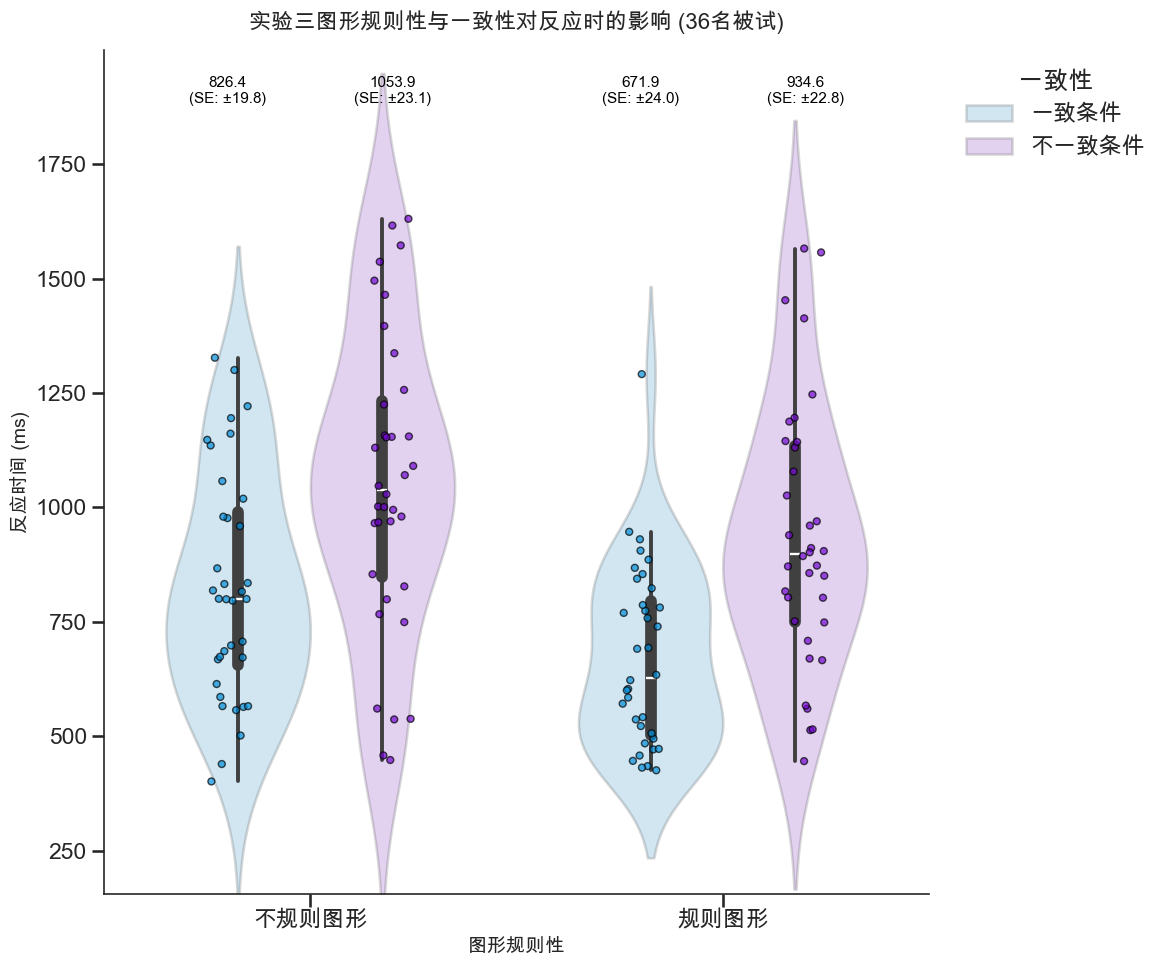



====== 报 告 专 用 数 据 (反应时, 校正后) ======
[不规则图形 - 一致条件]
  均值 (Mean)  : 826.4 ms
  标准误 (SE)  : ±19.8 ms
  95%置信区间 : [786.1, 866.6] (半宽: ±40.3)
---------------------------------------------
[不规则图形 - 不一致条件]
  均值 (Mean)  : 1053.9 ms
  标准误 (SE)  : ±23.1 ms
  95%置信区间 : [1007.1, 1100.7] (半宽: ±46.8)
---------------------------------------------
[规则图形 - 一致条件]
  均值 (Mean)  : 671.9 ms
  标准误 (SE)  : ±24.0 ms
  95%置信区间 : [623.3, 720.6] (半宽: ±48.7)
---------------------------------------------
[规则图形 - 不一致条件]
  均值 (Mean)  : 934.6 ms
  标准误 (SE)  : ±22.8 ms
  95%置信区间 : [888.3, 981.0] (半宽: ±46.3)
---------------------------------------------


====== 反应时主效应统计与正文文字生成 ======
【你可以直接复制以下这段话放入论文中】
对受试者反应时的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间未表现出显著的交互作用（F(1, 35) = 1.42, p = .242, ηp² = 0.001）。由于交互作用不显著，分析重点转向两大主效应。
结果表明，注意一致性的主效应...（F(1, 35) = 64.67, p < .001, ηp² = 0.177）：由于其具备主效应，受试者在注意一致条件下的反应时（M = 749.1 ms, 95% CI [705.4, 792.9]）可能在统计上不同于注意不一致条件（M = 994.3 ms, 95% CI [950.5, 1038.0]）[请自行完善描述]。
同理，语义规则性的主效应..

In [7]:
# 多份文件的数据处理与方差分析 - 反应时分析(RT)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from matplotlib.font_manager import FontProperties
import traceback

# 设置中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'PingFang SC', 'Microsoft YaHei', 'STHeiti', 'Heiti SC', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'sans-serif'
    font = FontProperties(family='sans-serif', size=12)
except Exception as e:
    print(f"字体设置出错: {e}")

# 创建输出文件夹
output_folder = os.path.join(os.getcwd(), '多被试分析结果_ANOVA_RT')
os.makedirs(output_folder, exist_ok=True)

# 数据文件路径
data_path = '/Users/zhangqianqian/Documents/PKU/实验/实验三数据'

try:
    # 读取并合并所有数据
    all_data = []
    subject_count = 0
    file_count = 0
    
    # 检查目录是否存在
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"找不到目录: {data_path}")
    
    print(f"开始读取目录: {data_path}")
    
    # 列出所有文件
    all_files = sorted(os.listdir(data_path))
    excel_files = [f for f in all_files if f.lower().endswith(('.xlsx', '.xls'))]
    
    print(f"目录中找到 {len(excel_files)} 个Excel文件")
    
    # 处理每个文件
    for file_name in excel_files:
        try:
            file_count += 1
            file_path = os.path.join(data_path, file_name)
            print(f"处理文件 {file_count}/{len(excel_files)}: {file_name}")
            
            # 读取Excel文件
            df = pd.read_excel(file_path)
            print(f"  - 包含 {len(df)} 行数据")
            
            # 提取被试ID - 从文件名或文件内容
            subject_id = None
            try:
                # 尝试从文件名中提取数字作为被试ID
                import re
                subject_id_matches = re.findall(r'\d+', file_name)
                if subject_id_matches:
                    subject_id = int(subject_id_matches[0])
                # 如果文件中已有Subject列，使用它的唯一值
                elif 'Subject' in df.columns:
                    subject_id = df['Subject'].unique()[0]
            except Exception as ex:
                print(f"  - 从文件名提取被试ID时出错: {ex}")
                
            # 如果无法提取ID，使用递增的计数
            if subject_id is None:
                subject_count += 1
                subject_id = subject_count
            else:
                subject_count = max(subject_count, subject_id)
                
            print(f"  - 被试ID: {subject_id}")
            
            # 添加/更新被试ID列
            df['SubjectID'] = subject_id
            
            # 保存原始列名
            original_columns = df.columns.tolist()
            
            # 检查RT列是否存在
            if 'RT' not in df.columns:
                print(f"  - 警告: 文件缺少RT列，无法进行反应时分析")
                continue  # 跳过这个文件
                
            # 提取必要的信息 - 与之前的代码相同
            df['shape_str'] = df['Shape'].astype(str)
            df['左侧数字'] = df['shape_str'].str[0].astype(int)
            df['右侧数字'] = df['shape_str'].str[1].astype(int)
            
            # 分析不同条件
            df['条件类型'] = '未分类'
            df['一致性'] = '未分类'
            df['被查看的数字'] = np.nan
            df['被查看的位置'] = '未分类'
            df['图形规则性'] = '未分类'
            
            # 左手一致条件 (Cue=0, Report=0)：看左侧图形
            left_consistent = (df['Cue'] == 0) & (df['Report'] == 0)
            df.loc[left_consistent, '条件类型'] = '左手一致'
            df.loc[left_consistent, '一致性'] = '一致条件'
            df.loc[left_consistent, '被查看的数字'] = df.loc[left_consistent, '左侧数字']
            df.loc[left_consistent, '被查看的位置'] = '左侧'
            df.loc[left_consistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_consistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手一致条件 (Cue=1, Report=1)：看右侧图形
            right_consistent = (df['Cue'] == 1) & (df['Report'] == 1)
            df.loc[right_consistent, '条件类型'] = '右手一致'
            df.loc[right_consistent, '一致性'] = '一致条件'
            df.loc[right_consistent, '被查看的数字'] = df.loc[right_consistent, '右侧数字']
            df.loc[right_consistent, '被查看的位置'] = '右侧'
            df.loc[right_consistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_consistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 左手不一致条件 (Cue=0, Report=1)：看右侧图形
            left_inconsistent = (df['Cue'] == 0) & (df['Report'] == 1)
            df.loc[left_inconsistent, '条件类型'] = '左手不一致'
            df.loc[left_inconsistent, '一致性'] = '不一致条件'
            df.loc[left_inconsistent, '被查看的数字'] = df.loc[left_inconsistent, '右侧数字']
            df.loc[left_inconsistent, '被查看的位置'] = '右侧'
            df.loc[left_inconsistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_inconsistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手不一致条件 (Cue=1, Report=0)：看左侧图形
            right_inconsistent = (df['Cue'] == 1) & (df['Report'] == 0)
            df.loc[right_inconsistent, '条件类型'] = '右手不一致'
            df.loc[right_inconsistent, '一致性'] = '不一致条件'
            df.loc[right_inconsistent, '被查看的数字'] = df.loc[right_inconsistent, '左侧数字']
            df.loc[right_inconsistent, '被查看的位置'] = '左侧'
            df.loc[right_inconsistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_inconsistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 确保feedback列存在，用于筛选正确试次
            if 'feedback' in df.columns:
                df['是否正确'] = df['feedback'].astype(int)
            else:
                print(f"  - 警告: 文件缺少feedback列，假设所有试次都正确")
                df['是否正确'] = 1
            
            # 移除shape_str临时列
            if 'shape_str' in df.columns:
                df = df.drop('shape_str', axis=1)
            
            # 添加这个处理好的数据到列表
            all_data.append(df)
            
        except Exception as e:
            print(f"处理文件 {file_name} 时出错: {e}")
            traceback.print_exc()
    
    print(f"\n成功处理了 {len(all_data)} 个文件，共 {subject_count} 名被试的数据")

    # 合并所有被试数据
    if not all_data:
        raise ValueError("没有成功处理任何数据")
        
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"合并后的数据包含 {len(df_all)} 行")
    
    # 剔除无效RT
    print(f"剔除无效RT前的数据量：{len(df_all)}")
    df_all = df_all[df_all['RT'] != -999].copy()  # 剔除无效RT
    print(f"剔除无效RT后的数据量：{len(df_all)}")
    
    # 只保留正确试次进行反应时分析（常规做法）
    print(f"仅保留正确试次前的数据量：{len(df_all)}")
    df_all = df_all[df_all['是否正确'] == 1].copy()  # 只保留正确试次
    print(f"仅保留正确试次后的数据量：{len(df_all)}")
    
    # RT单位转换（如果需要）
    # 通常RT记录单位应该是秒，将其转换为毫秒以方便解读
    df_all['RT_ms'] = df_all['RT'] * 1000  # 转换为毫秒
    
    # 排除异常的RT（可选步骤）
    # 定义异常RT的范围，例如<200ms或>2000ms
    outliers = (df_all['RT_ms'] < 200) | (df_all['RT_ms'] > 2000)
    if outliers.any():
        print(f"检测到 {outliers.sum()} 个RT异常值 (<200ms 或 >2000ms)")
        print(f"剔除异常RT前的数据量：{len(df_all)}")
        df_all = df_all[~outliers].copy()
        print(f"剔除异常RT后的数据量：{len(df_all)}")
    
    # 按被试和条件统计RT
    subject_stats = df_all.groupby(['SubjectID', '图形规则性', '一致性'])['RT_ms'].agg([
        ('平均RT', 'mean'),
        ('RT中位数', 'median'),
        ('RT标准差', 'std'),
        ('试次数', 'count')
    ]).reset_index()
    
    print("\n===== 各被试各条件反应时间 =====")
    print(subject_stats.head())
    
    # 按条件计算平均反应时间
    rt_stats = subject_stats.groupby(['图形规则性', '一致性'])[['平均RT', 'RT中位数']].agg([
        ('平均值', 'mean'),
        ('标准差', 'std'),
        ('标准误', lambda x: x.std() / np.sqrt(len(x))),
        ('被试数', 'count')
    ]).reset_index()
    
    print("\n===== 各条件的平均反应时间 (ms) =====")
    print(rt_stats)
    
    # 保存汇总表
    subject_stats.to_excel(os.path.join(output_folder, '各被试条件反应时间.xlsx'), index=False)
    
    # 重新组织数据以便于显示
    rt_summary = pd.DataFrame({
        '条件': ['规则一致', '规则不一致', '不规则一致', '不规则不一致'],
        '平均RT (ms)': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].mean()
        ],
        '标准误': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]))
        ]
    })
    
    print("\n===== 条件汇总 =====")
    print(rt_summary)
    
    # ===== 进行方差分析 =====
    print("\n===== 开始进行反应时的重复测量方差分析 =====")
    
    try:
        # 检查每个被试是否在所有条件下都有数据
        condition_count = subject_stats.groupby('SubjectID').size()
        valid_subjects = condition_count[condition_count == 4].index.tolist()
        
        if len(valid_subjects) < subject_count:
            print(f"警告: 有 {subject_count - len(valid_subjects)} 名被试不具备所有条件的数据")
            print(f"只有 {len(valid_subjects)} 名被试将被用于方差分析")
        
        # 只保留有完整数据的被试
        valid_data = subject_stats[subject_stats['SubjectID'].isin(valid_subjects)]
        
        # 使用pingouin进行重复测量方差分析
        aov = pg.rm_anova(
            data=valid_data,
            dv='平均RT',
            within=['图形规则性', '一致性'],
            subject='SubjectID',
            detailed=True
        )
        
        print("\n重复测量方差分析结果:")
        print(aov)
        
        # 保存ANOVA结果
        aov.to_excel(os.path.join(output_folder, '反应时方差分析结果.xlsx'), index=False)
        
        # 获取ANOVA的p值
        p_values = {}
        for _, row in aov.iterrows():
            source = row['Source']
            p = row['p-unc']
            p_values[source] = p
        
                # ===== 绘制基于 Cousineau-Morey 校正的高级纯净版风琴图 =====
        import scipy.stats as stats
        
        # 1. 计算 Cousineau-Morey 校正数据 (去除被试间变异)
        k = 4 # 2x2 实验设计共计 4 个条件
        N = len(valid_subjects)
        t_crit = stats.t.ppf(0.975, df=N-1)
        
        grand_mean = valid_data['平均RT'].mean()
        valid_data['rt_norm'] = valid_data['平均RT'] - valid_data.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean
        morey_correction = np.sqrt(k / (k - 1))
        
        summary_plot = (valid_data.groupby(['图形规则性', '一致性'])
                   .agg(mean=('平均RT','mean'),
                        se_ws=('rt_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
                   .reset_index())
        summary_plot['se_ws'] *= morey_correction
        summary_plot['ci_95'] = summary_plot['se_ws'] * t_crit
        
        # 2. 准备绘图底板
        sns.set_theme(style='ticks', context='talk')
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        rule_order = ['不规则图形', '规则图形']
        cons_order = ['一致条件', '不一致条件']
        
        # 沿用ACC的专属高级颜色：一致为青色，不一致为紫红色
        custom_colors = ["#028DD8", "#7205D1"] 
        
        # 3. 绘制平滑小提琴图 (风琴图)
        sns.violinplot(
            data=valid_data, x='图形规则性', y='平均RT', hue='一致性',
            order=rule_order, hue_order=cons_order,
            inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.2
        )
        
        # 4. 叠加抖动散点以呈现真实数据点分布
        sns.stripplot(
            data=valid_data, x='图形规则性', y='平均RT', hue='一致性',
            order=rule_order, hue_order=cons_order,
            dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
        )
        
        # 5. Y轴范围动态调整
        y_max = valid_data['平均RT'].max()
        y_min = valid_data['平均RT'].min()
        yr = y_max - y_min
        ax.set_ylim(y_min - 0.2 * yr, y_max + 0.3 * yr)
        
        # 6. 计算标注重合文本位置并画出 (均值与SE)
        for i, rule in enumerate(rule_order):
            for j, cons in enumerate(cons_order):
                offset = -0.2 if j == 0 else 0.2
                x_pos = i + offset
                row = summary_plot.loc[(summary_plot['图形规则性']==rule) & (summary_plot['一致性']==cons)].iloc[0]
                m_val = row['mean']
                se_val = row['se_ws']
                
                # 图上文字：在风琴图上方保留平均值与 SE (不带百分号)
                ax.text(x_pos, y_max + 0.2 * yr, f'{m_val:.1f}\n(SE: ±{se_val:.1f})',
                        ha='center', va='bottom', fontsize=11, color='black')

        # 7. 图表样式润色
        title_str = f'实验三图形规则性与一致性对反应时的影响 ({N}名被试)'
        ax.set_title(title_str, fontsize=16, pad=15)
        ax.set_xlabel('图形规则性', fontsize=14)
        ax.set_ylabel('反应时间 (ms)', fontsize=14)
        
        # 整理图例
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > len(cons_order):
            ax.legend(handles=handles[:len(cons_order)], labels=cons_order, title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        else:
            ax.legend(title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

        # 边框去边
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for side in ['left','bottom']:
            ax.spines[side].set_linewidth(1.2)

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, '反应时_风琴图_纯净版.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_folder, '反应时_风琴图_纯净版.pdf'), bbox_inches='tight')
        plt.show()

        # ====== 新增计算：打印专属报告数据表格（带校正后95% CI） ======
        print("\n\n" + "="*45)
        print("====== 报 告 专 用 数 据 (反应时, 校正后) ======")
        print("="*45)
        for idx, row in summary_plot.iterrows():
            rule = row['图形规则性']
            cons = row['一致性']
            m_val = row['mean']
            se_val = row['se_ws']
            ci_val = row['ci_95']
            print(f"[{rule} - {cons}]")
            print(f"  均值 (Mean)  : {m_val:.1f} ms")
            print(f"  标准误 (SE)  : ±{se_val:.1f} ms")
            print(f"  95%置信区间 : [{m_val - ci_val:.1f}, {m_val + ci_val:.1f}] (半宽: ±{ci_val:.1f})")
            print("-" * 45)

        # ====== 自动化文字生成（主效应） ======
        print("\n\n" + "="*45)
        print("====== 反应时主效应统计与正文文字生成 ======")
        print("="*45)
        
        eff_col = 'np2' if 'np2' in aov.columns else 'ng2'
        
        f_rule = aov.loc[aov['Source'] == '图形规则性', 'F'].values[0]
        p_rule = aov.loc[aov['Source'] == '图形规则性', 'p-unc'].values[0]
        np2_rule = aov.loc[aov['Source'] == '图形规则性', eff_col].values[0]
        
        f_cons = aov.loc[aov['Source'] == '一致性', 'F'].values[0]
        p_cons = aov.loc[aov['Source'] == '一致性', 'p-unc'].values[0]
        np2_cons = aov.loc[aov['Source'] == '一致性', eff_col].values[0]
        
        f_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'F'].values[0]
        p_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'p-unc'].values[0]
        np2_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', eff_col].values[0]
        
        ddof1 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof1'].values[0])
        ddof2 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof2'].values[0])
        
        df_cons_main = valid_data.groupby(['SubjectID', '一致性'])['平均RT'].mean().reset_index()
        k_main = 2 
        morey_corr_main = np.sqrt(k_main / (k_main - 1))
        t_crit_main = stats.t.ppf(0.975, df=N-1)
        
        grand_mean_main1 = df_cons_main['平均RT'].mean()
        df_cons_main['norm'] = df_cons_main['平均RT'] - df_cons_main.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean_main1
        sum_cons = df_cons_main.groupby('一致性').agg(mean=('平均RT','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_cons['se'] *= morey_corr_main
        sum_cons['ci_95'] = sum_cons['se'] * t_crit_main
        
        con_m, con_ci = sum_cons.loc['一致条件', 'mean'], sum_cons.loc['一致条件', 'ci_95']
        incon_m, incon_ci = sum_cons.loc['不一致条件', 'mean'], sum_cons.loc['不一致条件', 'ci_95']

        df_rule_main = valid_data.groupby(['SubjectID', '图形规则性'])['平均RT'].mean().reset_index()
        grand_mean_main2 = df_rule_main['平均RT'].mean()
        df_rule_main['norm'] = df_rule_main['平均RT'] - df_rule_main.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean_main2
        sum_rule = df_rule_main.groupby('图形规则性').agg(mean=('平均RT','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_rule['se'] *= morey_corr_main
        sum_rule['ci_95'] = sum_rule['se'] * t_crit_main

        reg_m, reg_ci = sum_rule.loc['规则图形', 'mean'], sum_rule.loc['规则图形', 'ci_95']
        irreg_m, irreg_ci = sum_rule.loc['不规则图形', 'mean'], sum_rule.loc['不规则图形', 'ci_95']
        
        def format_p(p):
            return "< .001" if p < 0.001 else f"= {p:.3f}".replace("= 0.", "= .")
            
        print("【你可以直接复制以下这段话放入论文中】")
        print(f"对受试者反应时的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间未表现出显著的交互作用（F({ddof1}, {ddof2}) = {f_int:.2f}, p {format_p(p_int)}, ηp² = {np2_int:.3f}）。由于交互作用不显著，分析重点转向两大主效应。")
        print(f"结果表明，注意一致性的主效应...（F({ddof1}, {ddof2}) = {f_cons:.2f}, p {format_p(p_cons)}, ηp² = {np2_cons:.3f}）：由于其具备主效应，受试者在注意一致条件下的反应时（M = {con_m:.1f} ms, 95% CI [{con_m-con_ci:.1f}, {con_m+con_ci:.1f}]）可能在统计上不同于注意不一致条件（M = {incon_m:.1f} ms, 95% CI [{incon_m-incon_ci:.1f}, {incon_m+incon_ci:.1f}]）[请自行完善描述]。")
        print(f"同理，语义规则性的主效应...（F({ddof1}, {ddof2}) = {f_rule:.2f}, p {format_p(p_rule)}, ηp² = {np2_rule:.3f}），受试者对语义规则图形的反应时（M = {reg_m:.1f} ms, 95% CI [{reg_m-reg_ci:.1f}, {reg_m+reg_ci:.1f}]）可能在统计上不同于非语义不规则图形（M = {irreg_m:.1f} ms, 95% CI [{irreg_m-irreg_ci:.1f}, {irreg_m+irreg_ci:.1f}]）[请自行完善描述]。")
        
         # 修复 Pandas 导出含有多级列索引数据框时的错误：
        # 先把 MultiIndex 列名扁平化（用下划线拼接），然后再保存
        if isinstance(rt_stats.columns, pd.MultiIndex):
            rt_stats.columns = ['_'.join(col).strip('_') for col in rt_stats.columns]

        # 保存RT汇总数据
        rt_stats.to_excel(os.path.join(output_folder, 'RT条件统计.xlsx'), index=False)
        rt_summary.to_excel(os.path.join(output_folder, 'RT条件汇总.xlsx'), index=False)
        
        # 可选：执行事后检验（如果方差分析有显著效应）
        if p_rule < 0.05 or p_con < 0.05 or p_int < 0.05:
            print("\n===== 进行事后检验 =====")
            
            if p_int < 0.05:  # 如果交互效应显著，进行简单效应分析
                print("交互效应显著，进行简单效应分析:")
                
                # 在规则图形下，一致性的效应
                regular_data = valid_data[valid_data['图形规则性'] == '规则图形']
                t_regular = pg.ttest(
                    regular_data[regular_data['一致性'] == '一致条件']['平均RT'], 
                    regular_data[regular_data['一致性'] == '不一致条件']['平均RT'],
                    paired=True
                )
                print("\n规则图形条件下，一致性效应:")
                print(t_regular)
                
                # 在不规则图形下，一致性的效应
                irregular_data = valid_data[valid_data['图形规则性'] == '不规则图形']
                t_irregular = pg.ttest(
                    irregular_data[irregular_data['一致性'] == '一致条件']['平均RT'], 
                    irregular_data[irregular_data['一致性'] == '不一致条件']['平均RT'],
                    paired=True
                )
                print("\n不规则图形条件下，一致性效应:")
                print(t_irregular)
                
                # 在一致条件下，规则性的效应
                consistent_data = valid_data[valid_data['一致性'] == '一致条件']
                t_consistent = pg.ttest(
                    consistent_data[consistent_data['图形规则性'] == '规则图形']['平均RT'], 
                    consistent_data[consistent_data['图形规则性'] == '不规则图形']['平均RT'],
                    paired=True
                )
                print("\n一致条件下，规则性效应:")
                print(t_consistent)
                
                # 在不一致条件下，规则性的效应
                inconsistent_data = valid_data[valid_data['一致性'] == '不一致条件']
                t_inconsistent = pg.ttest(
                    inconsistent_data[inconsistent_data['图形规则性'] == '规则图形']['平均RT'], 
                    inconsistent_data[inconsistent_data['图形规则性'] == '不规则图形']['平均RT'],
                    paired=True
                )
                print("\n不一致条件下，规则性效应:")
                print(t_inconsistent)
                
                # 保存事后检验结果
                with pd.ExcelWriter(os.path.join(output_folder, '反应时事后检验结果.xlsx')) as writer:
                    t_regular.to_excel(writer, sheet_name='规则图形下的一致性', index=False)
                    t_irregular.to_excel(writer, sheet_name='不规则图形下的一致性', index=False)
                    t_consistent.to_excel(writer, sheet_name='一致条件下的规则性', index=False)
                    t_inconsistent.to_excel(writer, sheet_name='不一致条件下的规则性', index=False)
            
            elif p_rule < 0.05:  # 如果只有规则性主效应显著
                print("规则性主效应显著，进行主效应配对比较:")
                
                # 合并一致和不一致条件，比较规则和不规则
                regular_rt = valid_data[valid_data['图形规则性'] == '规则图形']['平均RT']
                irregular_rt = valid_data[valid_data['图形规则性'] == '不规则图形']['平均RT']
                
                # 配对t检验
                t_result = pg.ttest(regular_rt, irregular_rt, paired=True)
                print(t_result)
                
                t_result.to_excel(os.path.join(output_folder, '规则性主效应t检验.xlsx'), index=False)
                
            elif p_con < 0.05:  # 如果只有一致性主效应显著
                print("一致性主效应显著，进行主效应配对比较:")
                
                # 合并规则和不规则条件，比较一致和不一致
                consistent_rt = valid_data[valid_data['一致性'] == '一致条件']['平均RT']
                inconsistent_rt = valid_data[valid_data['一致性'] == '不一致条件']['平均RT']
                
                # 配对t检验
                t_result = pg.ttest(consistent_rt, inconsistent_rt, paired=True)
                print(t_result)
                
                t_result.to_excel(os.path.join(output_folder, '一致性主效应t检验.xlsx'), index=False)
        
        print(f"\n分析结果已保存至: {output_folder}")
        
    except Exception as e:
        print(f"反应时方差分析过程中出错: {e}")
        traceback.print_exc()
        
        # 即使出错也尝试保存已处理的数据
        try:
            df_all.to_excel(os.path.join(output_folder, '已处理数据_处理中断.xlsx'), index=False)
        except:
            pass

except Exception as e:
    print(f"数据处理过程中出错: {e}")
    traceback.print_exc()